# **Spoticore Stage 3.0**: _WaveNet_

This notebook is a continuation of the _Stage 2.1_ code.

First, we introduce two new PyTorch-like APIs via the **Embedding**, **Flatten**, **FlattenConsecutive** and **Sequential** _Modules_.


### Imports


In [222]:
from typing import Final
from enum import Enum
import torch
import torch.nn.functional as F
import torch.nn.init as Init
from math import sqrt
from collections.abc import Iterator
from reader import read_all_unique_words
import random
from abc import ABC, abstractmethod


%matplotlib inline
import matplotlib.pyplot as plt

### Constants


In [ ]:
SEED: Final[int] = 534150593
N_EMBD: Final[int] = 24
N_HIDDEN: Final[int] = 34

BLOCK_SIZE: Final[int] = 8
CHUNK_SIZE: Final[int] = 2

### Initialize seed


In [224]:
torch.manual_seed(SEED);

### Build character-index mappings from training data


In [225]:
type StoiMap = dict[str, int]
type ItosMap = dict[int, str]


def build_vocab_mappings() -> tuple[list[str], StoiMap, ItosMap]:
    words = read_all_unique_words()

    # shuffle up the words
    random.seed(SEED)
    random.shuffle(words)

    chars = sorted(set("".join(words)))

    # create mappings with special token "." at index 0.
    stoi = {char: i + 1 for i, char in enumerate(chars)}
    stoi["."] = 0

    itos = {i: char for char, i in stoi.items()}

    return words, stoi, itos

### Construct model inputs from training data


In [226]:
words, stoi, itos = build_vocab_mappings()
vocab_size = len(stoi)

In [227]:
def construct_model_inputs(
    words: list[str], stoi: StoiMap, block_size: int = 8
) -> tuple[torch.Tensor, torch.Tensor]:
    X, Y = [], []

    for word in words:
        prev_chars_is = [0] * block_size
        for char in word + ".":
            nxt_char_i = stoi[char]
            X.append(prev_chars_is)
            Y.append(nxt_char_i)
            prev_chars_is = prev_chars_is[1:] + [nxt_char_i]
    X, Y = torch.tensor(X), torch.tensor(Y)
    print("X:", X.shape, "Y:", Y.shape)
    return X, Y

### Module architecture


In [228]:
class Module(ABC):
    def __init__(self) -> None:
        super().__init__()
        self.training = True
        self.out = torch.zeros(1)

    @abstractmethod
    def __call__(self, x: torch.Tensor) -> torch.Tensor: ...
    @abstractmethod
    def parameters(self) -> Iterator[torch.Tensor]: ...

In [229]:
class Linear(Module):
    def __init__(self, fan_in: int, fan_out: int, bias: bool = True) -> None:
        # Kaiming initialization: scale by 1/√fan_in to maintain unit variance.
        # Gain for non-linearities (e.g., tanh) is applied separately in model setup.
        super().__init__()
        self.weight = torch.randn((fan_in, fan_out)) / sqrt(fan_in)
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self) -> Iterator[torch.Tensor]:
        yield self.weight
        if self.bias is not None:
            yield self.bias

Note:

> In the Pytorch API, the [_BatchNorm1d_](https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html) class expects an input tensor of shape $[Batch, Channel, Time]$ when an instance is called. Note that the channel dimension is in the middle.

However, our implementation below expects an input tensor of shape $[Batch, Time, Channel]$ as it is more intuitve and easier to reason about.


In [230]:
class BatchNorm1d(Module):
    def __init__(
        self, num_features: int, eps: float = 1e-5, momentum: float = 0.1
    ) -> None:
        super().__init__()
        self.eps = eps
        self.momentum = momentum
        # bn gain.
        self.gamma = torch.ones(num_features)
        # bn bias.
        self.beta = torch.zeros(num_features)
        # bn running mean and variance.
        self.running_mean = torch.zeros(num_features)
        self.running_var = torch.ones(num_features)

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        # Forward pass: calculate activations.
        if self.training:
            # Support for 3d (and n dim) input tensors
            # via stats calculation along all batch dims
            # See note above.
            xmean = x.mean(tuple(range(x.ndim - 1)), keepdim=True)
            xvar = x.var(tuple(range(x.ndim - 1)), keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var

        # Normalize to unit variance.
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)

        self.out = self.gamma * xhat + self.beta

        # Update running mean and var.
        if self.training:
            with torch.no_grad():
                self.running_mean = (
                    1 - self.momentum
                ) * self.running_mean + self.momentum * xmean
                self.running_var = (
                    1 - self.momentum
                ) * self.running_var + self.momentum * xvar

        return self.out

    def parameters(self) -> Iterator[torch.Tensor]:
        yield self.gamma
        yield self.beta

In [231]:
class Embedding(Module):
    def __init__(self, num_embeddings: int, embedding_dim: int = 10) -> None:
        super().__init__()
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX: torch.Tensor) -> torch.Tensor:
        self.out = self.weight[IX]
        # correct dimensions for next module's dot product
        return self.out

    def parameters(self) -> Iterator[torch.Tensor]:
        yield self.weight

In [232]:
class Flatten(Module):
    def __init__(self) -> None:
        super().__init__()

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        self.out = x.view(x.shape[0], -1)
        return self.out

    def parameters(self) -> Iterator[torch.Tensor]:
        return iter(())

In [ ]:
class FlattenConsecutive(Module):
    def __init__(self, n: int) -> None:
        super().__init__()
        self.n = n

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        B, L, C = x.shape  # Batches, Sequence Length, Channels
        self.out = x.view(B, L // self.n, C * self.n)
        if self.out.shape[1] == 1:
            self.out = self.out.squeeze(1)
        return self.out

    def parameters(self) -> Iterator[torch.Tensor]:
        return iter(())

In [234]:
class Tanh(Module):
    def __init__(self) -> None:
        super().__init__()

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        self.out = torch.tanh(x)
        return self.out

    def parameters(self) -> Iterator[torch.Tensor]:
        return iter(())

In [235]:
class Sequential(Module):
    def __init__(self, modules: list[Module]) -> None:
        super().__init__()
        self.modules = modules

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        for module in self.modules:
            x = module(x)

        self.out = x
        return self.out

    def parameters(self) -> Iterator[torch.Tensor]:
        for module in self.modules:
            yield from module.parameters()

### Create deep WaveNet


In [236]:
model = Sequential(
    [  # Input Module.
        Embedding(vocab_size, N_EMBD),
        # Hidden Layer 1
        FlattenConsecutive(CHUNK_SIZE),
        Linear(N_EMBD * CHUNK_SIZE, N_HIDDEN, bias=False),
        BatchNorm1d(N_HIDDEN),
        Tanh(),
        # Hidden Layer 2
        FlattenConsecutive(CHUNK_SIZE),
        Linear(N_HIDDEN * CHUNK_SIZE, N_HIDDEN, bias=False),
        BatchNorm1d(N_HIDDEN),
        Tanh(),
        # Hidden Layer 3
        FlattenConsecutive(CHUNK_SIZE),
        Linear(N_HIDDEN * CHUNK_SIZE, N_HIDDEN, bias=False),
        BatchNorm1d(N_HIDDEN),
        Tanh(),
        # Output Module
        Linear(N_HIDDEN, vocab_size),
    ]
)

#### Kaiming Init for tanh


In [237]:
gain = Init.calculate_gain("tanh")

# Make last module less confident.
with torch.no_grad():
    # If last module is batchnorm.
    # modules[-1].gamma *= 0.1
    # If last module is linear.
    model.modules[-1].weight *= 0.1

    # Apply gain for all tanh pre-activations.
    # Output module does not perform tanh.
    for module in model.modules[:-1]:
        if isinstance(module, Linear):
            module.weight *= gain

### Initialize model parameters for training


In [238]:
params = list(model.parameters())
print("Total parameters: ", sum(p.nelement() for p in params))

# Ensure all parameters take part in backpropagation.
for p in params:
    p.requires_grad = True

Total parameters:  8643


### Split model inputs into datasets


In [239]:
sep1 = int(0.8 * len(words))
sep2 = int(0.9 * len(words))

Xtr, Ytr = construct_model_inputs(words[:sep1], stoi)
Xval, Yval = construct_model_inputs(words[sep1:sep2], stoi)
Xte, Yte = construct_model_inputs(words[sep2:], stoi)

X: torch.Size([531800, 8]) Y: torch.Size([531800])
X: torch.Size([66555, 8]) Y: torch.Size([66555])
X: torch.Size([66815, 8]) Y: torch.Size([66815])


#### First 20 $(\text{input}, \text{output})$ sets:


In [240]:
for x, y in zip(Xtr[:20], Ytr[:20]):
    print("".join(itos[i.item()] for i in x), "-->", itos[y.item()])

........ --> u
.......u --> n
......un --> d
.....und --> e
....unde --> r
...under --> p
..underp --> a
.underpa --> y
underpay --> .
........ --> t
.......t --> r
......tr --> o
.....tro --> u
....trou --> p
...troup --> .
........ --> c
.......c --> h
......ch --> e
.....che --> w
....chew --> e


### Train the model


In [241]:
iterations = 200_000
batch_size = 32
lr = 0.2

# Loss in iterations passed through log10().
losses = []


for i in range(iterations):
    # Construct mini batch of inputs.
    chosen_idxs = torch.randint(0, Xtr.shape[0], (batch_size,))

    # Extract the batches.
    Xb, Yb = Xtr[chosen_idxs], Ytr[chosen_idxs]

    # Forward pass.
    logits = model(Xb)

    loss = F.cross_entropy(logits, Yb)

    # Backward pass.
    for p in params:
        p.grad = None

    loss.backward()

    # Update params.
    lr = 0.2 if i < 150_000 else 0.01
    for p in params:
        if p.grad is not None:
            p.data += -lr * p.grad

    # Track stats.
    if i % 10_000 == 0:
        print(f"{i:7d} / {iterations}: {loss.item():.4f}")

    losses.append(loss.log10().item())


print(f"\nFinal loss: {loss.item():.4f}")

      0 / 200000: 3.6087
  10000 / 200000: 2.4458
  20000 / 200000: 2.2156
  30000 / 200000: 2.5593
  40000 / 200000: 2.0924
  50000 / 200000: 2.2870
  60000 / 200000: 2.2666
  70000 / 200000: 2.4322
  80000 / 200000: 2.0799
  90000 / 200000: 2.7599
 100000 / 200000: 2.3366
 110000 / 200000: 2.3435
 120000 / 200000: 2.1926
 130000 / 200000: 2.2240
 140000 / 200000: 2.1275
 150000 / 200000: 2.1616
 160000 / 200000: 2.3226
 170000 / 200000: 1.9814
 180000 / 200000: 2.3090
 190000 / 200000: 1.8326

Final loss: 2.3687


### Loss vs iteration

We see below that the loss fluctuates every iteration due to mini-batch noise over 200 000 iterations.

Note:

> When we pass a 1D array to `plt.plot()`, it treats the indices (0 to 199) as the X-axis and the averaged loss values as the Y-axis.


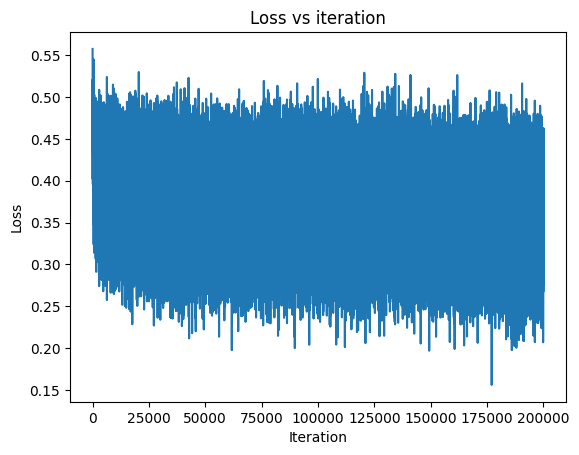

In [242]:
plt.plot(losses)
plt.title("Loss vs iteration")
plt.xlabel("Iteration")
plt.ylabel("Loss");

#### Downsampled loss vs iteration

Downsampling is the process of reducing the number of data points in a dataset while trying to preserve the most important information called the _signal_.
In our plot above, the signal is the underlying curve that shows the loss decreasing over time.

There are different methods of downsampling. We will be using _averaging_/_binning_ technique where we calculate `mean()` for every 1000 losses. An alternative technique is _stridding_ where we grab the 1000th loss (`losses[0]`, `losses[1000]`, `losses[2000]`) instead. The mean technique is better because the average of 1000 points is more representative of the 1000 datapoint window than one single random point. In other words, it preserves the _signal_ better.

**Why do we downsample?**

Observe that we cannot infer whether the loss is going down/up (among other possible observations) from the plot above. Downsampling helps to soften the effect of the mini-batch noise and reveals the "skeleton curve" or general trend of the loss.


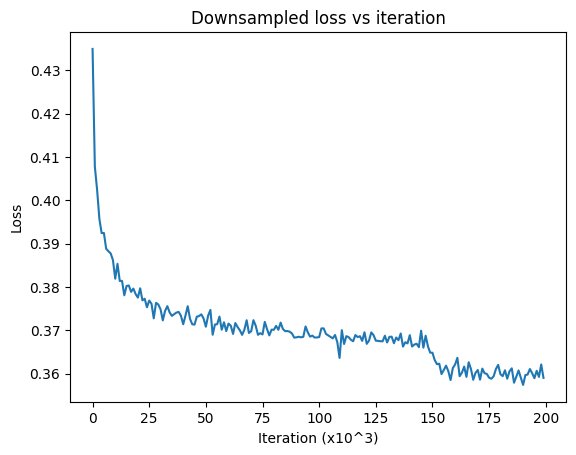

In [243]:
plt.plot(torch.tensor(losses).view(-1, 1000).mean(1))
plt.title("Downsampled loss vs iteration")
plt.xlabel("Iteration (x10^3)")
plt.ylabel("Loss");

### Model evaluation


In [244]:
# make BatchNorm layers,use running statistics instead of batch statistics. Also stops updating these stats.
for module in model.modules:
    module.training = False

In [245]:
# evaluate the loss
class Loss(str, Enum):
    TRAIN = "training_loss"
    VAL = "validation_loss"
    TEST = "testing_loss"


@torch.no_grad()
def print_split_loss(split: Loss) -> None:
    if split == Loss.TRAIN:
        x, y = Xtr, Ytr
    elif split == Loss.VAL:
        x, y = Xval, Yval
    else:
        x, y = Xte, Yte
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

In [246]:
print_split_loss(Loss.TRAIN)
print_split_loss(Loss.VAL)

Loss.TRAIN 2.2781102657318115
Loss.VAL 2.2875678539276123


#### Performance log

| block size | chunk size | n_embd | n_hidden | n_layers | params | train loss | val loss |
| ---------- | ---------- | ------ | -------- | -------- | ------ | ---------- | -------- |
| 8          | 8          | 24     | 128      | 3        | 64157  | 2.139      | 2.198    |
| 8          | 2          | 24     | 128      | 3        | 78109  | 2.134      | 2.193    |
| 8          | 2          | 24     | 68       | 3        | 25609  | 2.204      | 2.235    |
| 8          | 2          | 24     | 34       | 3        | 8643   | 2.278      | 2.288    |


### Model sampling


In [247]:
for _ in range(20):
    out = []
    context = [0] * BLOCK_SIZE
    while True:
        # forward pass with trained params
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        embd_idx = torch.multinomial(probs, 1, replacement=True).item()
        context = context[1:] + [embd_idx]
        out.append(embd_idx)
        if embd_idx == 0:
            break
    print("".join(itos[i] for i in out))

890h.
carler.
pompordabum.
missch.
cauat.
merner.
ununcin.
overswaed.
birendade.
kimcwaya.
moitweela.
mekainling.
palopies.
cotcrscim.
fornigh.
deranst.
dralisabalantitre.
pacnal.
owassency.
malene.


## Appendix

This section contains model diagnosis and testing conducted while this notebook was developed, preserved for posterity.


### Layer output shapes

Analyze how activation shapes change as the inputs are processed from layer to layer by the model in the forward pass.


In [257]:
# small input batch size as example
ix = torch.randint(0, Xtr.shape[0], (4,))
Xb, Yb = Xtr[ix], Ytr[ix]
# perform forward pass
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0,  0, 17, 28, 19],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0, 17, 28, 15, 19],
        [ 0,  0,  0,  0,  0, 29, 26, 11]])

In [258]:
# print each layer's output shape
for module in model.modules:
    print(module.__class__.__name__, ":", tuple(module.out.shape))

Embedding : (4, 8, 24)
FlattenConsecutive : (4, 4, 48)
Linear : (4, 4, 34)
BatchNorm1d : (4, 4, 34)
Tanh : (4, 4, 34)
FlattenConsecutive : (4, 2, 68)
Linear : (4, 2, 34)
BatchNorm1d : (4, 2, 34)
Tanh : (4, 2, 34)
FlattenConsecutive : (4, 68)
Linear : (4, 34)
BatchNorm1d : (4, 34)
Tanh : (4, 34)
Linear : (4, 37)


### Sneaky BatchNorm1D bug

This bug is hard to notice because the model seems to work fine with no errors after introducing **FlattenConsecutive** layers.

The bug was that the initial BatchNorm implementation only worked with 2d input tensors. The batch statistics are not calculated along the correct dimensions for tensors with dims > 2.

Buggy code looked like this:


In [259]:
x = torch.randn((4, 4, 68))
xmean = x.mean(0, keepdim=True)
xvar = x.var(0, keepdim=True)
xhat = (x - xmean) / torch.sqrt(xvar + 1e-5)
xhat.shape

torch.Size([4, 4, 68])

#### Mean along dim(0) vs dim((0,1))

Remember that mean collapses dimension(s) into a single value.


In [260]:
x = torch.tensor(
    [
        [[1.0, 10.0], [2.0, 20.0], [3.0, 30.0]],  # Batch 0
        [[4.0, 40.0], [5.0, 50.0], [6.0, 60.0]],  # Batch 1
    ]
)

Calculating mean over dim(0) [batches]:

$$\text{mean}_0=\frac{\text{sum of all elements in [time step, channel] slot}}{\text{ total batches}}$$
$$\text{mean}_0=\frac{1.0+4.0}{2}, \frac{10.0+40.0}{2}, \frac{2.0+5.0}{2}, ... $$

For the output shape, we keep original dims(1,2) shape while collapsing dim(0) to 1 (removing dim 0 altogether if keepdim = False):

$$[ [ [2.5, 25.0], [3.5,35.0], [4.5, 45.0] ] ]$$


In [261]:
print(f"{x.shape =}")
mean0 = x.mean(0, keepdim=True)
print(f"{mean0 =}")

x.shape =torch.Size([2, 3, 2])
mean0 =tensor([[[ 2.5000, 25.0000],
         [ 3.5000, 35.0000],
         [ 4.5000, 45.0000]]])


Calculating mean over dims(0,1) [batches, time steps]:

$$\text{mean}_{01}=\frac{\text{sum of all elements in each [channel] slot}}{\text{total batches * total sequence length}}$$
$$\text{mean}_{01}=\frac{1.0+2.0+3.0+4.0+5.0+6.0}{6}, \frac{10.0+20.0+ 30.0+40.0+50.0+60.0}{6} $$

For the output shape, we keep original dim(2) shape while collapsing dim(0,1) to 1 and 1 (removing dim 0 and 1 altogether if keepdim = False):

$$[ [[3.5, 35.0]] ]$$


In [262]:
print(f"{x.shape =}")
mean01 = x.mean((0, 1), keepdim=True)
print(f"{mean01 =}")

x.shape =torch.Size([2, 3, 2])
mean01 =tensor([[[ 3.5000, 35.0000]]])


#### Consequence of the bug

Initial implementation only calculates mean over dim(0) for 3d tensors. This means that we are not calculating the mean over the inputs to each channel/feature like BatchNorm should.

Instead, we are calculating a separate mean and variance for every single time step in the sequence.

**What BatchNorm should do:**

For a 3D input of shape _(Batch, Time, Channels)_, BatchNorm should normalize each channel across ALL batch examples AND ALL time steps in the sequence.

This means calculating one mean and one variance per channel by averaging over both the batch dimension (0) and time dimension (1) so that each channel gets normalized consistently, regardless of position in the sequence.

**What the bug does:**

- Produces separate statistics for each time step
- The model incorrectly learns that features at time step 0 should be normalized differently than features at time step 5

**Consequences:**

- Different positions use different normalization scales
- The model treats sequential position as part of the feature distribution, when it should be position-invariant


In [263]:
# Create a simple 3D tensor: (Batch=2, Time=3, Channels=2)
x = torch.tensor(
    [
        [[1.0, 10.0], [2.0, 20.0], [3.0, 30.0]],  # Batch 0
        [[4.0, 40.0], [5.0, 50.0], [6.0, 60.0]],  # Batch 1
    ]
)

print("Shape:", x.shape)  # (2, 3, 2)

# WRONG: mean(0) - only batch dimension
mean_wrong = x.mean(0, keepdim=True)
print("\nWrong mean shape:", mean_wrong.shape)
print(mean_wrong)
# Bug: Each time step gets its own mean

# RIGHT: mean((0,1)) - both batch and time
mean_right = x.mean((0, 1), keepdim=True)
print("\nRight mean shape:", mean_right.shape)
print(mean_right)
# Channel 0: [1,2,3,4,5,6] → mean = 3.5
# Channel 1: [10,20,30,40,50,60] → mean = 35.0

Shape: torch.Size([2, 3, 2])

Wrong mean shape: torch.Size([1, 3, 2])
tensor([[[ 2.5000, 25.0000],
         [ 3.5000, 35.0000],
         [ 4.5000, 45.0000]]])

Right mean shape: torch.Size([1, 1, 2])
tensor([[[ 3.5000, 35.0000]]])


### Tensor concatenation

`torch.cat()` concatenates tensors along an existing dimension:

- All tensors must have the same shape except in the concatenation dimension
- dim=0: stack along batch dimension (increases batch size)
- dim=1: stack along time/sequence dimension (increases sequence length)
- dim=2: stack along feature/channel dimension (increases feature count)


#### Example 1

If we have two tensors of shape (4, 4, 10) and concatenate on dim=2,
the result will be (4, 4, 20) - same batch and time, but doubled features.


In [264]:
m = torch.randn(4, 4, 10)
out = torch.cat((m, torch.randn_like(m)), dim=2)
out.shape

torch.Size([4, 4, 20])

#### Example 2


In [265]:
ex = torch.randn(4, 8, 10)
print(f"{ex.shape = }")

evens = ex[:, ::2, :]
print(f"{evens.shape = }")

odds = ex[:, 1::2, :]
print(f"{odds.shape = }")

explicit = torch.cat((evens, odds), 2)
print(f"{explicit.shape = }")

ex.shape = torch.Size([4, 8, 10])
evens.shape = torch.Size([4, 4, 10])
odds.shape = torch.Size([4, 4, 10])
explicit.shape = torch.Size([4, 4, 20])
